In [60]:
import numpy as np
import pandas as pd

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [62]:
df=pd.read_csv('Iris.csv', index_col='Id')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [63]:
X=df.drop('Species',axis=1).to_numpy()
y=df[['Species']].to_numpy()

In [64]:
scaler=StandardScaler()
onehot_encoder=OneHotEncoder(sparse_output=False)
enc_y=onehot_encoder.fit_transform(y)
scaled_X=scaler.fit_transform(X)

In [65]:
cat_array=onehot_encoder.categories_[0]


In [66]:
X_train,X_test,y_train,y_test=train_test_split(scaled_X,enc_y,test_size=0.2,shuffle=True,stratify=enc_y,random_state=999)

## Model Creation and compile

In [67]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD,Adam

In [68]:
inp_shape=X_train.shape[1]

In [69]:
num_classes=y_train.shape[1]

In [70]:
model=Sequential()
model.add(Input(shape=(inp_shape,))) #Input layer
model.add(Dense(10,activation='relu')) ##Hidden Layer
model.add(Dense(6,activation='relu'))# Hidden Layer

model.add(Dense(num_classes,activation='softmax')) #Output layer
model.compile(optimizer=Adam(learning_rate=0.1),loss='categorical_crossentropy',metrics=['accuracy'])

In [71]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137 (548.00 B)

 Trainable params: 137 (548.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
history=model.fit(
    X_train,y_train,epochs=50,batch_size=64
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 461ms/step - accuracy: 0.1917 - loss: 1.1869
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5417 - loss: 1.0003
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7167 - loss: 0.7327 
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8833 - loss: 0.4082
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9250 - loss: 0.2170
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9667 - loss: 0.1076
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9583 - loss: 0.0799
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9750 - loss: 0.0749
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9750 - loss: 0.0558
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9750 - loss: 0.0451
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9833 - loss: 0.0401
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9833 - loss: 0.0420

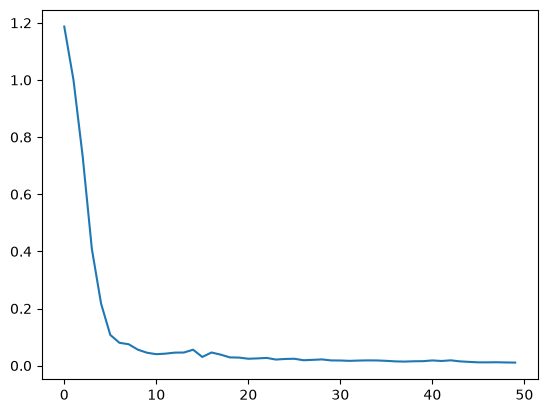

In [73]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [74]:
loss,accuracy=model.evaluate(X_test,y_test)
accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9667 - loss: 0.2753


0.9666666388511658

In [80]:
y_true=np.argmax(y_test,axis=1)
y_true

array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 2, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [79]:
y_pred=np.argmax(model.predict(X_test),axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1, 2,
       1, 2, 0, 1, 2, 1, 0, 2])

In [76]:
cat_array

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [77]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score

In [81]:
confusion_matrix(y_true,y_pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]])

In [82]:
accuracy_score(y_true,y_pred)

0.9666666666666667

In [83]:
recall_score(y_true,y_pred,average="weighted")

0.9666666666666667

In [ ]:
f1_score(y_true,y_pred,average='macro')

In [ ]:
precision_score(y_true,y_pred,average='macro')

0.9696969696969697